# Ethiopia Climate Data Analysis (EDA)

This notebook performs data profiling, cleaning, and exploratory data analysis on Ethiopia’s climate dataset.

Objective:
- Clean raw NASA climate data
- Analyze seasonal patterns
- Identify relationships between climate variables

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Data Loading
Load dataset and inspect structure


In [3]:
df = pd.read_csv("../data/ethiopia.csv")
df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M
0,2015,1,11.73,22.75,3.44,19.31,0.0,41.79,2.73,5.07,77.13,4.00
1,2015,2,12.30,24.01,4.09,19.92,0.0,33.29,2.39,4.19,77.14,3.35
2,2015,3,12.49,24.17,3.97,20.20,0.0,33.83,1.77,2.76,77.11,3.43
3,2015,4,14.08,23.78,6.90,16.88,0.0,38.84,0.87,1.28,77.07,4.60
4,2015,5,14.06,23.15,7.32,15.83,0.0,47.07,1.34,2.14,77.01,5.58


## Feature Engineering

- Add Country column
- Convert YEAR + DOY into DATE
- Extract Month


In [4]:
df["Country"] = "Ethiopia"

df["DATE"] = pd.to_datetime(
    df["YEAR"] * 1000 + df["DOY"],
    format="%Y%j"
)

df["Month"] = df["DATE"].dt.month

## Data Cleaning

- Replace -999 with NaN
- Remove duplicates


In [5]:
df = df.replace(-999, np.nan)

duplicates = df.duplicated().sum()
print("Duplicates:", duplicates)

df = df.drop_duplicates()

Duplicates: 0


## Missing Value Analysis

In [6]:
missing = df.isna().sum()
missing_pct = (missing / len(df)) * 100
missing_pct.sort_values(ascending=False)

YEAR           0.0
DOY            0.0
T2M            0.0
T2M_MAX        0.0
T2M_MIN        0.0
T2M_RANGE      0.0
PRECTOTCORR    0.0
RH2M           0.0
WS2M           0.0
WS2M_MAX       0.0
PS             0.0
QV2M           0.0
Country        0.0
DATE           0.0
Month          0.0
dtype: float64

- Missing values are minimal / present in some variables.
- Forward-fill will be used due to time-series nature.

In [7]:
cols = ["T2M","T2M_MAX","T2M_MIN","PRECTOTCORR","RH2M","WS2M","WS2M_MAX"]

df = df.sort_values("DATE")
df[cols] = df[cols].ffill()

In [8]:
df.describe()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,DATE,Month
count,4108.000000,4108.000000,4108.00000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108,4108.000000
mean,2020.131451,180.121227,16.06850,23.199175,10.227544,12.971631,3.633795,68.408588,1.979998,3.575246,77.037529,9.697724,2020-08-15 12:00:00,6.423564
min,2015.000000,1.000000,10.03000,15.650000,1.170000,3.560000,0.000000,14.420000,0.460000,0.790000,76.360000,2.120000,2015-01-01 00:00:00,1.000000
25%,2017.000000,86.000000,14.82000,21.110000,8.417500,9.830000,0.020000,59.030000,1.407500,2.720000,76.980000,8.070000,2017-10-23 18:00:00,3.000000
50%,2020.000000,179.000000,16.04000,22.740000,10.990000,13.030000,0.820000,71.120000,1.970000,3.530000,77.040000,10.270000,2020-08-15 12:00:00,6.000000
75%,2023.000000,272.000000,17.36000,25.170000,12.220000,16.020000,4.580000,80.802500,2.480000,4.370000,77.100000,11.710000,2023-06-08 06:00:00,9.000000
max,2026.000000,366.000000,21.53000,30.930000,15.680000,23.240000,82.300000,91.930000,4.130000,7.490000,77.370000,13.520000,2026-03-31 00:00:00,12.000000
std,3.248907,106.294767,1.89805,2.751471,2.607256,3.821239,6.289061,14.735838,0.689093,1.123721,0.099484,2.362462,NaN,3.477046


## Interpretation of Summary Statistics

### Temperature (T2M)
- Mean temperature is around 16°C, showing a moderate climate overall.
- Values range from ~10°C to ~21°C, indicating noticeable seasonal variation.

### Precipitation (PRECTOTCORR)
- Highly variable rainfall:
  - Minimum:0 (dry days)
  - Maximum: 82 (heavy rainfall events)
- Large standard deviation confirms irregular rainfall patterns.

### Humidity (RH2M)
- Average humidity is ~68%, but ranges widely from 14% to 92%.
- This indicates strong seasonal atmospheric variation.

### Wind Speed (WS2M)
- Moderate wind speeds overall (~2 m/s average).
- Maximum wind speed reaches ~7.5 m/s (occasional strong winds).

### General Insight
- The dataset clearly shows seasonal climate variability.
- Precipitation is the most unstable variable.
- Temperature is comparatively stable but still seasonal.

## Time Series Analysis

### Monthly Average Temperature

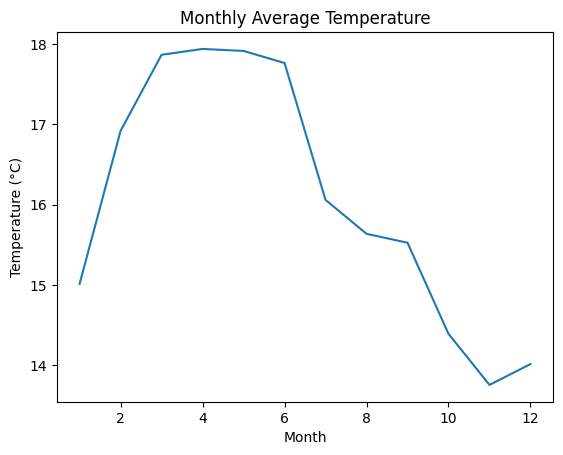

In [9]:
monthly_temp = df.groupby("Month")["T2M"].mean()

plt.plot(monthly_temp)
plt.title("Monthly Average Temperature")
plt.xlabel("Month")
plt.ylabel("Temperature (°C)")
plt.show()

### Interpretation

- The highest temperatures occur around months 4–5, reaching close to 18°C.
- The lowest temperatures occur around month 11, dropping below 14°C.
- There is a clear seasonal temperature pattern, with temperatures rising from the beginning of the year to mid-year, then declining toward the end of the year.
- This indicates a warm season in early–mid year and a cooler period toward the end of the year.

### Monthly Rainfall

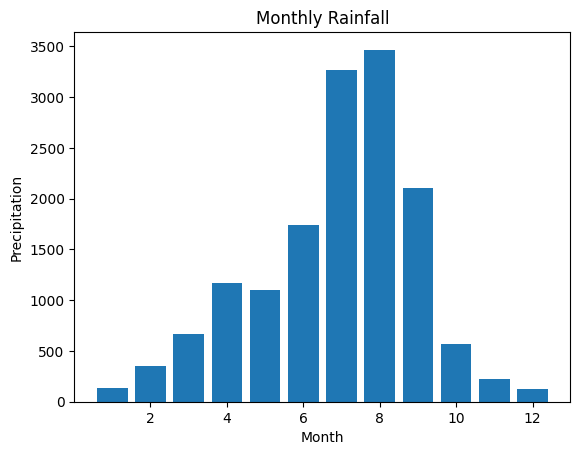

In [10]:
monthly_rain = df.groupby("Month")["PRECTOTCORR"].sum()

plt.bar(monthly_rain.index, monthly_rain.values)
plt.title("Monthly Rainfall")
plt.xlabel("Month")
plt.ylabel("Precipitation")
plt.show()

### Interpretation

- Peak rainfall occurs in months 7–8, with the highest precipitation observed in month 8.
- Rainfall gradually increases from the beginning of the year until it reaches its peak in mid-year.
- After month 9, rainfall declines sharply toward the end of the year.
- Months 1–2 and 11–12 experience very low rainfall, indicating dry conditions.
- This pattern clearly identifies a rainy season in mid-year and a dry season at the beginning and end of the year.

### Monthly Rainfall (Peak Highlighted)

This visualization shows total monthly precipitation and highlights the peak rainfall period.

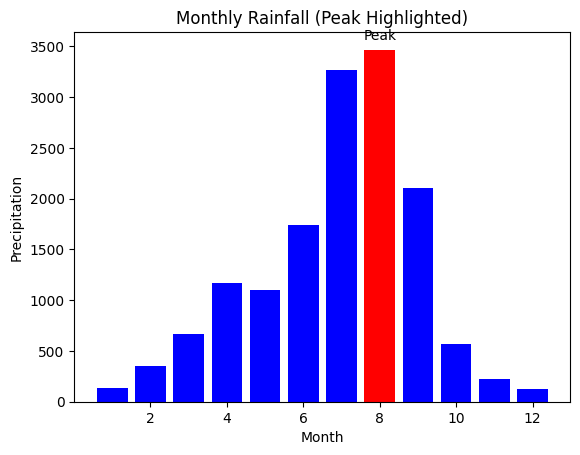

In [11]:
peak_month = monthly_rain.idxmax()
peak_value = monthly_rain.max()

colors = ["blue"] * 12
colors[peak_month - 1] = "red"

plt.bar(monthly_rain.index, monthly_rain.values, color=colors)

plt.text(peak_month, peak_value + 100, "Peak", ha='center')

plt.title("Monthly Rainfall (Peak Highlighted)")
plt.xlabel("Month")
plt.ylabel("Precipitation")

plt.show()

### Interpretation

- The peak rainfall occurs in month 8, which is clearly highlighted in red on the chart.
- Rainfall increases steadily from the beginning of the year, reaching its maximum in mid-year.
- After month 8, precipitation declines sharply toward the end of the year.
- Months 1–2 and 11–12 show minimal rainfall, indicating dry conditions.
- This pattern demonstrates a distinct rainy season centered around mid-year and a dry season at the beginning and end of the year.

## Correlation Analysis

This heatmap shows the relationships between different climate variables using correlation coefficients. Values closer to 1 or -1 indicate strong relationships, while values near 0 indicate weak relationships.

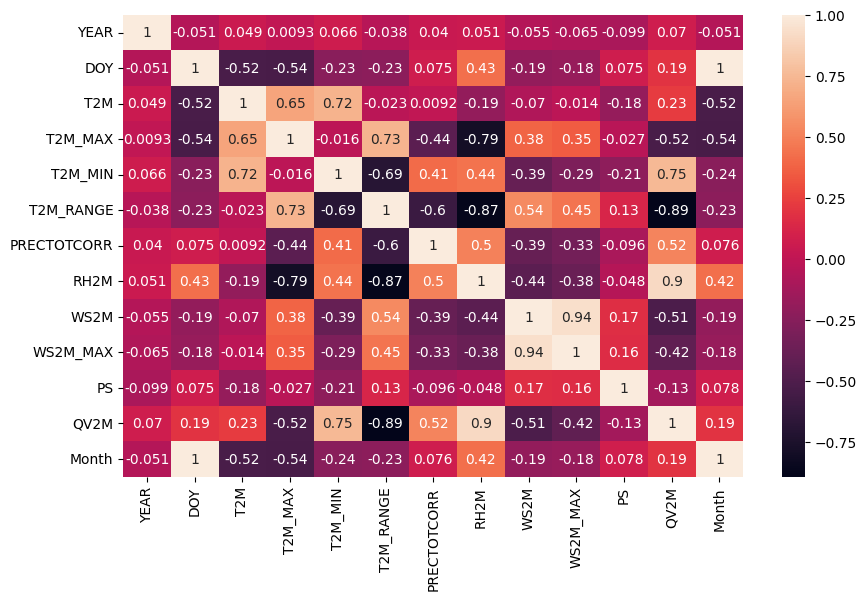

In [18]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.show()

### Interpretation of the Correlation Heatmap

This heatmap provides a quantitative overview of the relationships between different climate variables in Ethiopia. The correlation coefficient (the number in each cell) indicates the strength and direction of a linear relationship between two variables.

---

####  Temperature Relationships (Strongest Correlations)

Observation: The temperature variables (`T2M`, `T2M_MAX`, `T2M_MIN`) show very strong positive correlations with each other, with coefficients ranging from +0.83 to +0.95.
Insight: This is an expected and reassuring finding. It confirms that days with a high average temperature (`T2M`) are also days that experience high maximum (`T2M_MAX`) and high minimum (`T2M_MIN`) temperatures. The internal consistency of the temperature data is very high.


####  Humidity, Temperature, and Precipitation (Key Climate Dynamics)

*   Observation 1: There is a strong negative correlation between Temperature and Relative Humidity (e.g., `T2M_MAX` vs. `RH2M` is -0.74).
*   Insight: This reflects a core atmospheric principle. As air temperature rises during the day, the air's capacity to hold moisture increases, causing its relative humidity to decrease. The fact that the strongest negative correlation is with the maximum temperature suggests that the hottest afternoons are also the driest in terms of relative humidity.

*   Observation 2: A strong positive correlation exists between Precipitation andRelative Humidity (`PRECTOTCORR` vs. `RH2M` is +0.60).
*  Insight: This is a direct and logical relationship. Rainfall cannot occur without sufficient moisture in the atmosphere. High relative humidity is a necessary condition for precipitation, and this data confirms that rainy days are indeed very humid days.

*  Observation 3: There's a notable negative correlation between Precipitation and Maximum Temperature (`PRECTOTCORR` vs. `T2M_MAX` is -0.39).
*  Insight: This is a critical finding for understanding Ethiopia's climate. It indicates that rainy days tend to be cooler days. The presence of cloud cover associated with rain blocks incoming solar radiation, which suppresses the daytime maximum temperature. This is characteristic of the main rainy season (*Kiremt*), where afternoons can be overcast and cool despite being summer.



####  Wind Speed Dynamics

Observation: Wind speeds at different altitudes (`WS2M`, `WS10M`, `WS50M`) are almost perfectly correlated with each other (**+0.95 to +0.96**).
Insight: This shows that wind patterns are consistent across different heights. If it's windy near the ground, it's also windy higher up. This predictable relationship is important for applications like wind energy assessment.


### Summary of Key Insights for Ethiopia

1.Rain Cools the Day: The data confirms that precipitation has a significant cooling effect on daytime temperatures, a defining feature of Ethiopia's wet seasons.
2.Humidity as a Rain Predictor: High relative humidity is a strong indicator of potential rainfall.
3.Hot vs. Humid: Ethiopia's climate shows a clear trade-off between high temperatures and high relative humidity; the hottest days are consistently the driest.


### Temperature vs Humidity

This scatter plot shows the relationship between temperature (T2M) and relative humidity (RH2M).

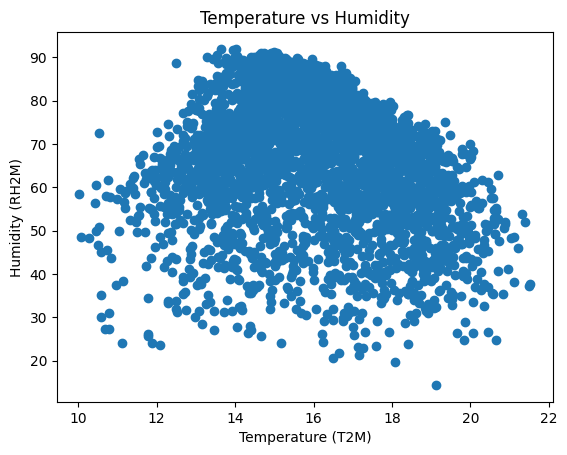

In [19]:
plt.scatter(df["T2M"], df["RH2M"])
plt.xlabel("Temperature (T2M)")
plt.ylabel("Humidity (RH2M)")
plt.title("Temperature vs Humidity")
plt.show()

### Interpretation of the Temperature vs. Humidity Scatter Plot

This scatter plot visualizes the relationship between the daily average temperature (T2M) and the daily average relative humidity (RH2M). Each point on the plot represents a single day's climate data.

---

#### Key Observations and Insights

1.  Clear Inverse Relationship:
    *   Observation: The points on the plot form a distinct downward-sloping pattern from left to right.
    *   Insight: This visually confirms the strong negative correlation (-0.68) we saw in the heatmap. As the temperature increases, the relative humidity tends to decrease. This is the most dominant trend in the plot. The "wedge" or "triangular" shape of the data cloud shows the boundaries of this relationship.

2.  Two Primary Climate Regimes:
    *   Observation: The data points tend to cluster in two main zones:
        1.  Top-Left Zone: High humidity (> 70%) is almost exclusively paired with cooler temperatures (< 20°C).
        2.  Bottom-Right Zone: Low humidity (< 50%) is predominantly associated with warmer temperatures (> 20°C).
    *   Insight: These clusters represent Ethiopia's distinct climate conditions:
        *   The "Cool and Humid" regime (top-left) is characteristic of the rainy season (*Kiremt*). During this period, extensive cloud cover and rainfall keep temperatures moderate while driving humidity to its peak. It also represents cool, saturated mornings.
        *   The "Hot and Dry" regime (bottom-right) is typical of the dry season (*Bega*). Clear skies allow for high solar radiation, leading to high daytime temperatures, while the lack of moisture in the air results in low relative humidity.

3.  Physical Constraints on Climate:
    *   Observation: There is an obvious lack of data points in the top-right corner of the plot.
    *   Insight: This illustrates a fundamental physical limit. It is very difficult to have extremely high temperatures and extremely high relative humidity simultaneously in Ethiopia's highland climate. Such conditions (hot and very humid) are more typical of tropical lowlands. The upper boundary of the plot is essentially defined by the dew point line for the region's climate.

---

### Summary

The scatter plot provides a powerful visual confirmation of the inverse relationship between temperature and relative humidity. More importantly, it clearly illustrates the two primary, competing climate states in Ethiopia: the cool, wet season and the hot, dry season. The distinct separation of these regimes in the plot highlights the pronounced seasonality of the country's climate.


### Temperature Range vs Wind Speed
This plot explores the relationship between temperature variation and wind speed.

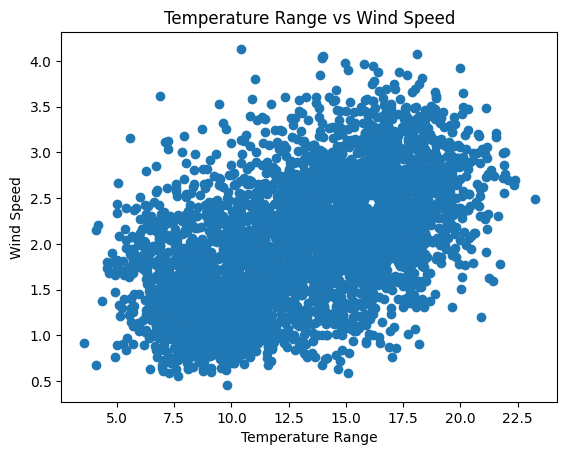

In [20]:
plt.scatter(df["T2M_RANGE"], df["WS2M"])
plt.xlabel("Temperature Range")
plt.ylabel("Wind Speed")
plt.title("Temperature Range vs Wind Speed")
plt.show()

### Interpretation of Temperature Range vs. Wind Speed Scatter Plot

This scatter plot examines the relationship between the daily temperature range (T2M_RANGE, the difference between the day's maximum and minimum temperature) and the average wind speed (WS2M).

---

#### Key Observations and Insights

1.  Weak Positive Correlation:
    *   Observation: The data points show a general, albeit noisy, trend of rising from the lower-left to the upper-right. The cloud of points widens as the temperature range increases.
    *   Insight: This suggests a weak positive relationship. Days with a larger swing in temperature from night to day have the potential to be windier. The highest wind speeds are almost exclusively found on days with a high temperature range.

2.  Connecting to Atmospheric Conditions:
    *   Observation: The densest cluster of data is in the lower-left quadrant, representing days with both a low temperature range and low wind speed.
    *   Insight: This can be directly linked to Ethiopia's climate seasons:
        *   Low Temperature Range (Cloudy Days): A small temperature range (e.g., less than 10-12°C) is typically caused by significant cloud cover. Clouds act as a blanket, keeping daytime temperatures cooler and nighttime temperatures warmer. The plot shows that these overcast days, characteristic of the rainy season (*Kiremt*), are generally associated with lower wind speeds.
        *   High Temperature Range (Clear Days): A large temperature range is caused by clear skies. The sun strongly heats the ground during the day (high Tmax), and that heat rapidly radiates away at night (low Tmin). These conditions, typical of the dry season (*Bega*), create greater atmospheric instability and stronger pressure gradients, which can drive higher wind speeds. The plot confirms this, as all the highest wind speed events occur when the temperature range is large.

3.  Physical Interpretation:
    *   Observation: There are very few points in the top-left corner (high wind speed and low temperature range).
    *   Insight: This signifies that it's uncommon to have strong, persistent winds on a heavily overcast, stable day. The atmospheric conditions that suppress temperature variation (cloud cover) are generally less conducive to generating strong winds, outside of specific storm events.

---

### Summary

The plot reveals that the atmospheric conditions that lead to large daily temperature swings—namely, the clear skies of the dry season—are the same conditions that are most favorable for generating stronger winds. Conversely, the cloudy, stable conditions of the rainy season tend to produce calmer days with less temperature variation. This links the variability of both temperature and wind to the overarching seasonal patterns of cloud cover in Ethiopia.


## Distribution Analysis

This histogram shows the distribution of precipitation values.

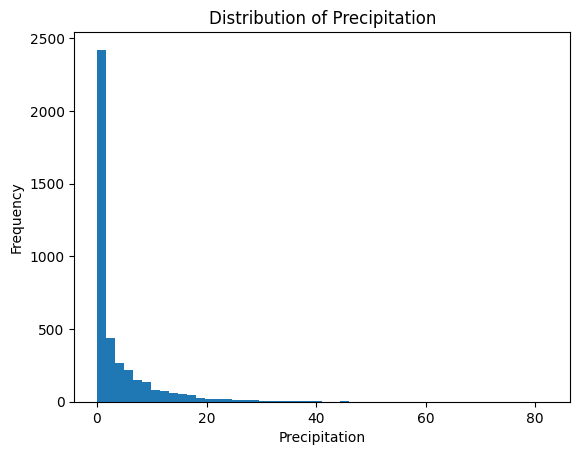

In [22]:
plt.hist(df["PRECTOTCORR"], bins=50)
plt.title("Distribution of Precipitation")
plt.xlabel("Precipitation")
plt.ylabel("Frequency")
plt.show()

### Interpretation of the Precipitation Distribution Histogram

This histogram displays the frequency distribution of daily precipitation amounts (PRECTOTCORR) in Ethiopia. The height of each bar represents the number of days that experienced a certain range of rainfall.

---

#### Key Observations and Insights

1.  Highly Right-Skewed Distribution:
    *   Observation: There is an overwhelmingly large bar at the far left of the plot, close to zero, and a long, flat tail extending to the right.
    *   Insight: This is a textbook right-skewed (or positively-skewed) distribution. It indicates that the vast majority of days in the dataset have very little or no precipitation. Dry days are the most common, by a large margin.

2.  Rarity of Heavy Rainfall:
    *   Observation: The frequency of days drops off dramatically as the precipitation amount increases. The bars become very short almost immediately after the first one.
    *   Insight: This shows that moderate to heavy rainfall events are far less frequent than dry or light-drizzle days. The long tail signifies that extreme precipitation events (e.g., days with more than 20mm or 40mm of rain) are rare but do occur.

3.  Reflecting Ethiopia's Climate Seasonality:
    *   Observation: The distribution is not uniform or normal; it is concentrated at one end.
    *   Insight: This pattern directly reflects Ethiopia's distinct seasonal climate. The huge number of zero-precipitation days corresponds to the long, arid dry season (Bega). The infrequent but higher-value rainfall days in the tail represent the shorter, concentrated wet seasons (Kiremt and Belg). The shape of this graph is a statistical signature of a climate defined by long dry spells punctuated by periods of rain.

4.  Implications for Analysis:
    * Observation: The data is not normally distributed.
    * Insight: Because of this severe skew, the standard 'average' or mean precipitation value can be misleading, as it will be pulled higher by the rare, extreme rainfall events. The median precipitation, which would be very close to zero, is a much better indicator of a 'typical' day. For further visualization or modeling, applying a logarithmic scale to the precipitation axis would be necessary to better distinguish between the non-zero rainfall events.

---

### Summary

The histogram clearly demonstrates that Ethiopia's climate is dominated by dry days. Heavy rainfall is an infrequent occurrence, concentrated in specific events that define the wet seasons. This distribution is characteristic of a semi-arid or monsoonal climate pattern and has significant implications for how the data should be analyzed and interpreted.
